In [1]:
from pathlib import Path


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid")

In [3]:
DATA_PATH = Path("../data/raw/combined_data.csv")

print(f"Dataset path:{DATA_PATH.resolve()}")
print(f"File exists:{DATA_PATH.exists()}")

Dataset path:/home/kavya/Documents/Studies/Bca/Projects/Spam_detection/Python-services/data/raw/combined_data.csv
File exists:True


In [5]:
df_raw = pd.read_csv(DATA_PATH)
if df_raw.empty == False:
    print("FIle loaded successfully")


FIle loaded successfully


In [5]:
# checking rows and columns
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

Number of rows: 83448
Number of columns: 2


In [6]:
print(df_raw.columns.tolist())

['label', 'text']


In [7]:
df_raw.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yo...
1,1,wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cial...
2,0,computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm ...
3,1,university degree obtain a prosperous future money earning power and the prestige that comes with having the career ...
4,0,thanks for all your answers guys i know i should have checked the rsync manual but i would rather get a escapenumber...


In [8]:
df_raw.sample(5, random_state=42)

,label,text
67681,0,accuweather escapenumber day forecast for beverly hills tonight l escapenumber a moonlit sky tomorrow h escapenumber...
61385,1,dear in christ the time has come for christians to worship god in spirit and in truth according to the book of john ...
41829,1,hallway cosponsor pry reimbursable coat clumsy dramaturgy gerard cotta exile charon seymour glottis brenda centum cu...
29172,1,does size matter' escapenumber of women said thay were unhappy with their lover's p size introducing the newest safe...
35274,0,along zeng wrote hi all is there levene' test in r if not could you give me some advice about levene test with r tha...


In [ ]:
spam_samples = df_raw[df_raw["label"] == 1].sample(
    3,
    random_state=42
)

not_spam_samples = df_raw[df_raw["label"] == 0].sample(
    3,
    random_state=42
)

In [10]:
spam_samples

,label,text
73411,1,wireless optical\n3 - button scroll mouse\nlimited\nstocks !\n$ 16 . 90\ncordless freedom with optical precision ! t...
27342,1,from the desk of philip moore\ndept credit control unit\nunion bank of nigeria\nall reply to my private email addres...
27216,1,submitting your website in search engines may increase\nyour online sales dramatically .\nlf you invested time and m...


In [11]:
not_spam_samples

,label,text
53671,0,umaru yar'adua candidate of nigeria's ruling pdp has won the country's controversial presidential election the elect...
16184,0,on tue jun escapenumber escapenumber at escapenumber escapenumber escapenumberpm escapenumber jra samba org wrote ma...
71476,0,"gentlemen ,\ni recommend that we purchase this package and split the cost 3 ways between 3\npower trading desks .\ni..."


In [13]:
df_raw.dtypes

label    int64
text       str
dtype: object

In [18]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   83448 non-null  int64
 1   text    83448 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.3 MB


In [19]:
print(f"Unique labels: {sorted(df_raw["label"].unique())}")

Unique labels: [np.int64(0), np.int64(1)]


In [20]:
label_names = {
    0 : "Not spam",
    1 : "spam"
}

print(f"{label_names}")

{0: 'Not spam', 1: 'spam'}


In [21]:
# checking for missing values, empty email txt, duplicate rows, email having duplicate text

quality_report = pd.DataFrame({
    "data_type": df_raw.dtypes.astype(str),
    "missing_values": df_raw.isnull().sum(),
    "missing_percentage": (df_raw.isnull().mean() * 100).round(2),
    "unique_values": df_raw.nunique()
})

quality_report

,data_type,missing_values,missing_percentage,unique_values
label,int64,0,0.0,2
text,str,0,0.0,83446


In [22]:
blank_text_count = (
    df_raw["text"].notna()
    & df_raw["text"].astype(str).str.strip().eq("")
).sum()

exact_duplicate_count = df_raw.duplicated().sum()

duplicate_text_count = df_raw.duplicated(
    subset=["text"]
).sum()

print("Blank email text:", blank_text_count)
print("Completely duplicated rows:", exact_duplicate_count)
print("Emails with duplicate text:", duplicate_text_count)

Blank email text: 0
Completely duplicated rows: 0
Emails with duplicate text: 2


In [7]:
duplicate_text_rows = df_raw[
    df_raw.duplicated(subset=["text"], keep=False)
].sort_values(by="text")

display(
    duplicate_text_rows[
        ["label", "text"]
    ]
)

,label,text
12425,0,hi
50633,1,hi
20516,0,unsubscribe
37213,1,unsubscribe


In [8]:
conflicting_texts = ["hi", "unsubscribe"]

df_clean = df_raw[
    ~df_raw["text"].isin(conflicting_texts)
].reset_index(drop=True)

In [9]:
print("Rows removed:", len(df_raw) - len(df_clean))
print(
    "Remaining duplicate texts:",
    df_clean.duplicated(subset=["text"]).sum()
)

Rows removed: 4
Remaining duplicate texts: 0


In [ ]:
non_spam_count = (df_clean["label"]== 0).sum()
spam_count = (df_clean["label"]== 1).sum()      #with manual method

print(f"Non spam email count: {non_spam_count}")
print(f"Spam email count: {spam_count}")

Non spam email count: 39536
Spam email count: 43908


In [ ]:
class_counts = df_clean["label"].value_counts()

print("Non-spam emails:", class_counts[0])
print("Spam emails:", class_counts[1])  #with valuecount function

Non-spam emails: 39536
Spam emails: 43908


In [13]:
print("Percentage")
print(
    (
        df_clean["label"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

Percentage
label
0    47.38
1    52.62
Name: proportion, dtype: float64


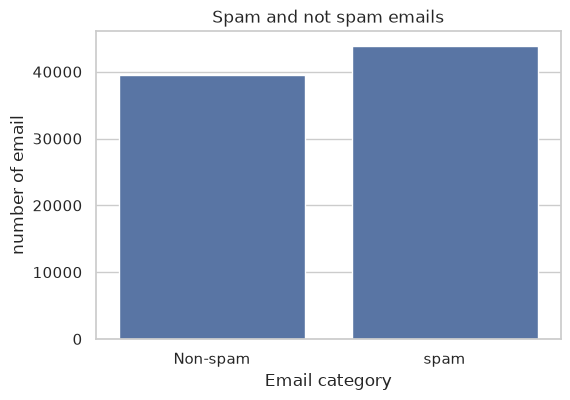

In [17]:
# plotting class distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data = df_clean,
    x="label",
    order=[0,1]
)

plt.xticks(
    ticks = [0,1],
    labels = ["Non-spam","spam"]
)

plt.title("Spam and not spam emails")
plt.xlabel("Email category")
plt.ylabel("number of email")

plt.show()

In [18]:
df_clean["character_count"] = df_clean["text"].str.len()

df_clean["word_count"] =( df_clean["text"].str.split().str.len())

display(
    df_clean[
        ["label","text","character_count","word_count"]
    ]
)

,label,text,character_count,word_count
0,1,ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yo...,148,20
1,1,wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cial...,808,103
2,0,computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm ...,2235,337
3,1,university degree obtain a prosperous future money earning power and the prestige that comes with having the career ...,592,76
4,0,thanks for all your answers guys i know i should have checked the rsync manual but i would rather get a escapenumber...,1362,222
...,...,...,...,...
83439,0,hi given a date how do i get the last date of that month i have data in the form yyyymm that i've read as a date usi...,2589,341
83440,1,now you can order software on cd or download it from our site immediately\ndelphi 7 . . our price : $ 40 . 00\nacrob...,616,118
83441,1,dear valued member canadianpharmacy provides a wide range of pharmaceutical products you will be surprised by the se...,534,76
83442,0,subscribe change profile contact us long term escapenumber day trend weather maps waterloo on monday april escapenum...,2113,277


character_count         word_count       
                 mean  median       mean median
label                                          
0             2121.80  1139.0     365.08  200.0
1             1249.94   704.0     208.76  122.0

In [20]:
CLEAN_DATA_PATH = (
    Path.cwd().parent
    /"data"
    /"clean"
    /"combined_clean_data.csv"
)

df_clean[["text","label"]].to_csv(CLEAN_DATA_PATH,index=False)

print(f"cleaned dataset saved successfully")
print(f"saved at: {CLEAN_DATA_PATH.resolve()}")
print(f"rows saved: {len(df_clean)}")

cleaned dataset saved successfully
saved at: /home/kavya/Documents/Studies/Bca/Projects/Spam_detection/Python-services/data/clean/combined_clean_data.csv
rows saved: 83444
